In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "lamborghini.jpeg"
img = cv.imread(path)

if img is None:
    print("Image not found")
else:
    print("Image loaded successfully")

Image loaded successfully


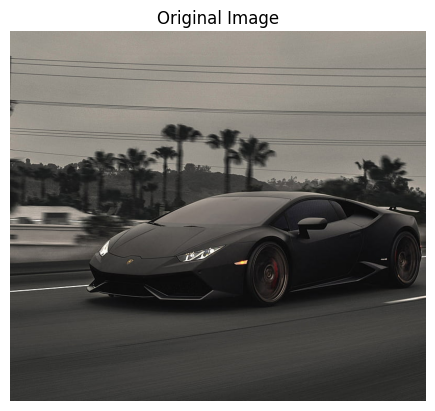

In [3]:
# Convert BGR to RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
# Getting image size and source points
h, w = img.shape[:2]
src_pts = np.float32([
    [0, 0],        # top-left
    [w, 0],        # top-right
    [w, h],        # bottom-right
    [0, h]         # bottom-left
])

In [5]:
# Define destination points
dst_pts = np.float32([
    [100, 100],          # shifted top-left
    [w-200, 0],         # compressed top-right
    [w, h],            # stretched bottom-right
    [0, h-200]          # shifted bottom-left
])

In [6]:
# Compute Homography Matrix
H = cv.getPerspectiveTransform(src_pts, dst_pts)
print("Homography Matrix:\n", H)

Homography Matrix:
 [[ 3.69704992e-01 -1.40646976e-01  1.00000000e+02]
 [-1.25000000e-01  3.69704992e-01  1.00000000e+02]
 [-4.25491679e-04 -4.07737924e-04  1.00000000e+00]]


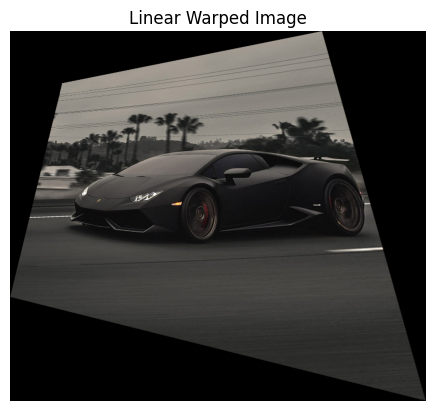

In [7]:
# Apply Warping
warped = cv.warpPerspective(img, H, (w, h))
warped_rgb = cv.cvtColor(warped, cv.COLOR_BGR2RGB)

plt.imshow(warped_rgb)
plt.title("Linear Warped Image")
plt.axis("off")
plt.show()

In [8]:
# Save this image
cv.imwrite("warped_lamborghini_1.png", warped)
print("Warped image saved")

Warped image saved


In [9]:
# Getting image size
rows, cols = img.shape[:2]

center_x = cols // 2
center_y = rows // 2

# Creating warping map
map_x = np.zeros((rows, cols), np.float32)
map_y = np.zeros((rows, cols), np.float32)

k = 0.00001  # distortion strength

for i in range(rows):
    for j in range(cols):

        dx = j - center_x
        dy = i - center_y

        r2 = dx*dx + dy*dy   # distance squared

        map_x[i, j] = j + k * dx * r2
        map_y[i, j] = i + k * dy * r2

In [10]:
# Display maps
print(map_x)
print()
print(map_y)

[[-1144.1    -1137.0518 -1130.0275 ...  1923.027   1930.0275  1937.0518]
 [-1141.264  -1134.2228 -1127.2056 ...  1920.2123  1927.2056  1934.2228]
 [-1138.436  -1131.4019 -1124.3917 ...  1917.4055  1924.3917  1931.4019]
 ...
 [-1138.436  -1131.4019 -1124.3917 ...  1917.4055  1924.3917  1931.4019]
 [-1141.264  -1134.2228 -1127.2056 ...  1920.2123  1927.2056  1934.2228]
 [-1144.1    -1137.0518 -1130.0275 ...  1923.027   1930.0275  1937.0518]]

[[-1015.38873 -1012.5523  -1009.72296 ... -1006.9007  -1009.72296
  -1012.5523 ]
 [-1009.0186  -1006.1902  -1003.3688  ... -1000.5545  -1003.3688
  -1006.1902 ]
 [-1002.6698   -999.8493   -997.0359  ...  -994.22955  -997.0359
   -999.8493 ]
 ...
 [ 1712.6698   1709.8492   1707.0359  ...  1704.2295   1707.0359
   1709.8492 ]
 [ 1719.0187   1716.1902   1713.3688  ...  1710.5544   1713.3688
   1716.1902 ]
 [ 1725.3888   1722.5522   1719.7229  ...  1716.9008   1719.7229
   1722.5522 ]]


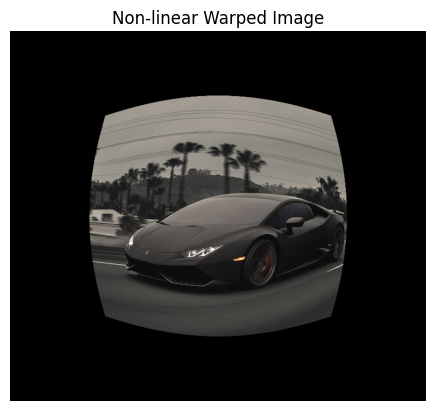

In [11]:
# Apply warping
warped = cv.remap(img, map_x, map_y, cv.INTER_LINEAR)

# Display warped image
warped_rgb = cv.cvtColor(warped, cv.COLOR_BGR2RGB)

plt.imshow(warped_rgb)
plt.title("Non-linear Warped Image")
plt.axis("off")
plt.show()

In [12]:
# Save this image
cv.imwrite("warped_lamborghini_2.png", warped)
print("Warped image saved")

Warped image saved
